In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

# quote_plus special characters ko encode karta hai
password = quote_plus(os.getenv('DB_PASSWORD'))

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{password}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)


# Load data
df_jobs = pd.read_sql("SELECT * FROM transformed_jobs", engine)
df_skills = pd.read_sql("SELECT * FROM job_skills", engine)

print(f"Jobs: {len(df_jobs)}")
print(f"Skills: {len(df_skills)}")

Jobs: 64
Skills: 330


In [ ]:
print(df_jobs.columns)
print(df_skills.columns)

Index(['id', 'job_title', 'company_name', 'job_description',
       'job_employment_type', 'job_city', 'job_country', 'job_apply_link',
       'posted_date', 'created_at', 'role_searched'],
      dtype='object')
Index(['job_id', 'job_title', 'company_name', 'skill', 'role_searched'], dtype='object')


TOP 10 SKILLS 

C:\Users\aadit\AppData\Local\Temp\ipykernel_12684\2280592264.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values,y=top_skills.index,palette='viridis')


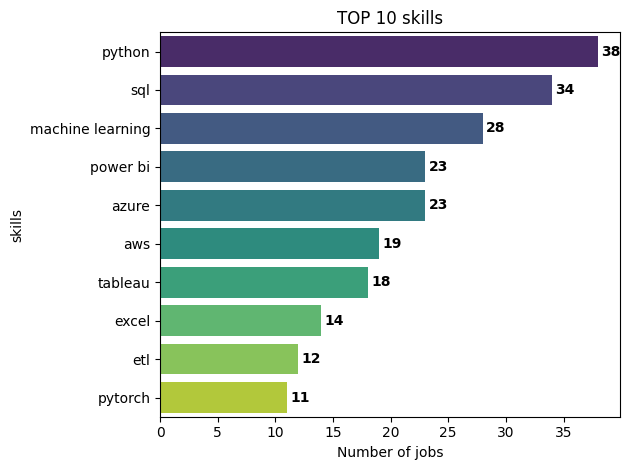

In [4]:
top_skills=df_skills['skill'].value_counts().head(10)
plt.Figure(figsize=(14,6))
plt.title("TOP 10 skills")
plt.xlabel('Number of jobs')
plt.ylabel('skills')
sns.barplot(x=top_skills.values,y=top_skills.index,palette='viridis')
for i, v in enumerate(top_skills.values):
    plt.text(v + 0.3, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_top_skills.png', dpi=150, bbox_inches='tight')
plt.show()

JOBS BY CITY

C:\Users\aadit\AppData\Local\Temp\ipykernel_12684\953155031.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.values, y=city_counts.index, palette='magma')


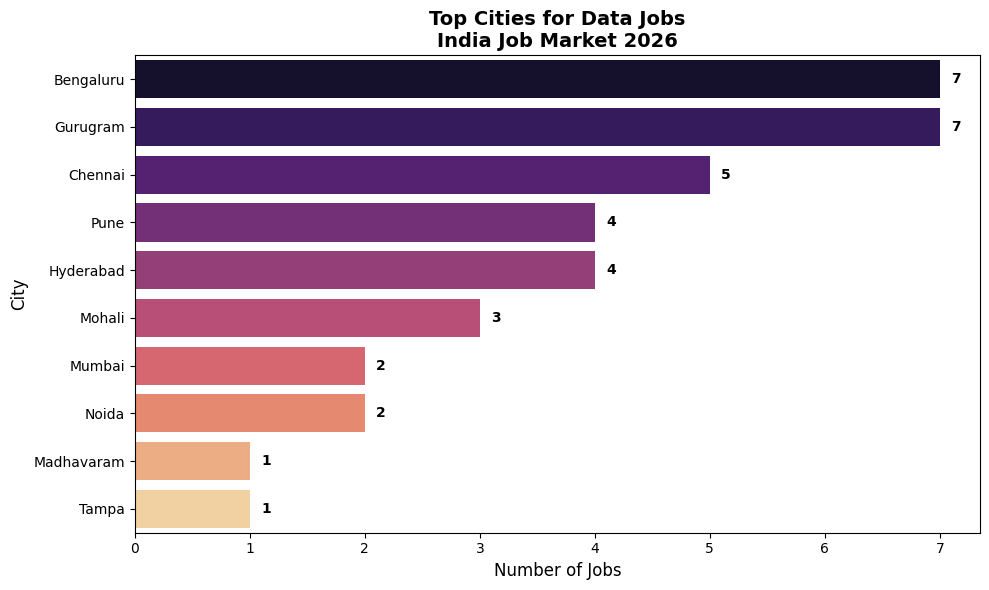

Chart 2 saved!


In [6]:
# ─── Chart 2: Jobs by City ───────────────────────
plt.figure(figsize=(10, 6))

city_counts = df_jobs[df_jobs['job_city'] != 'Unknown']['job_city'].value_counts().head(10)

sns.barplot(x=city_counts.values, y=city_counts.index, palette='magma')

plt.title('Top Cities for Data Jobs\nIndia Job Market 2026',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Jobs', fontsize=12)
plt.ylabel('City', fontsize=12)

for i, v in enumerate(city_counts.values):
    plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_jobs_by_city.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

ROLE WISE DISTRIBUTION

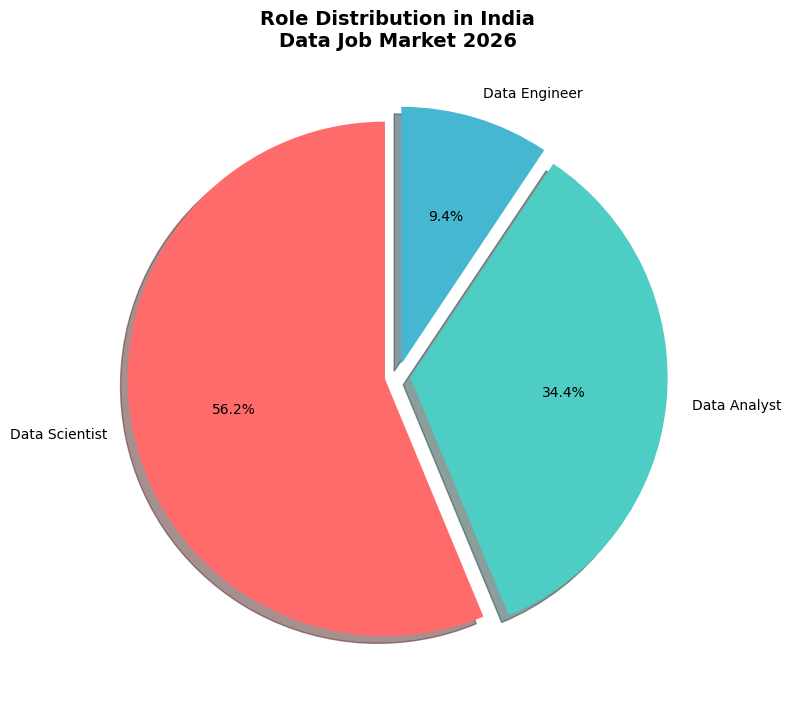

In [8]:
plt.figure(figsize=(8, 8))

role_counts = df_jobs['role_searched'].value_counts()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
explode = (0.05, 0.05, 0.05)

plt.pie(role_counts.values, 
        labels=role_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        shadow=True,
        startangle=90)

plt.title('Role Distribution in India\nData Job Market 2026',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_role_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

SKILLS BY ROLE GROUPED

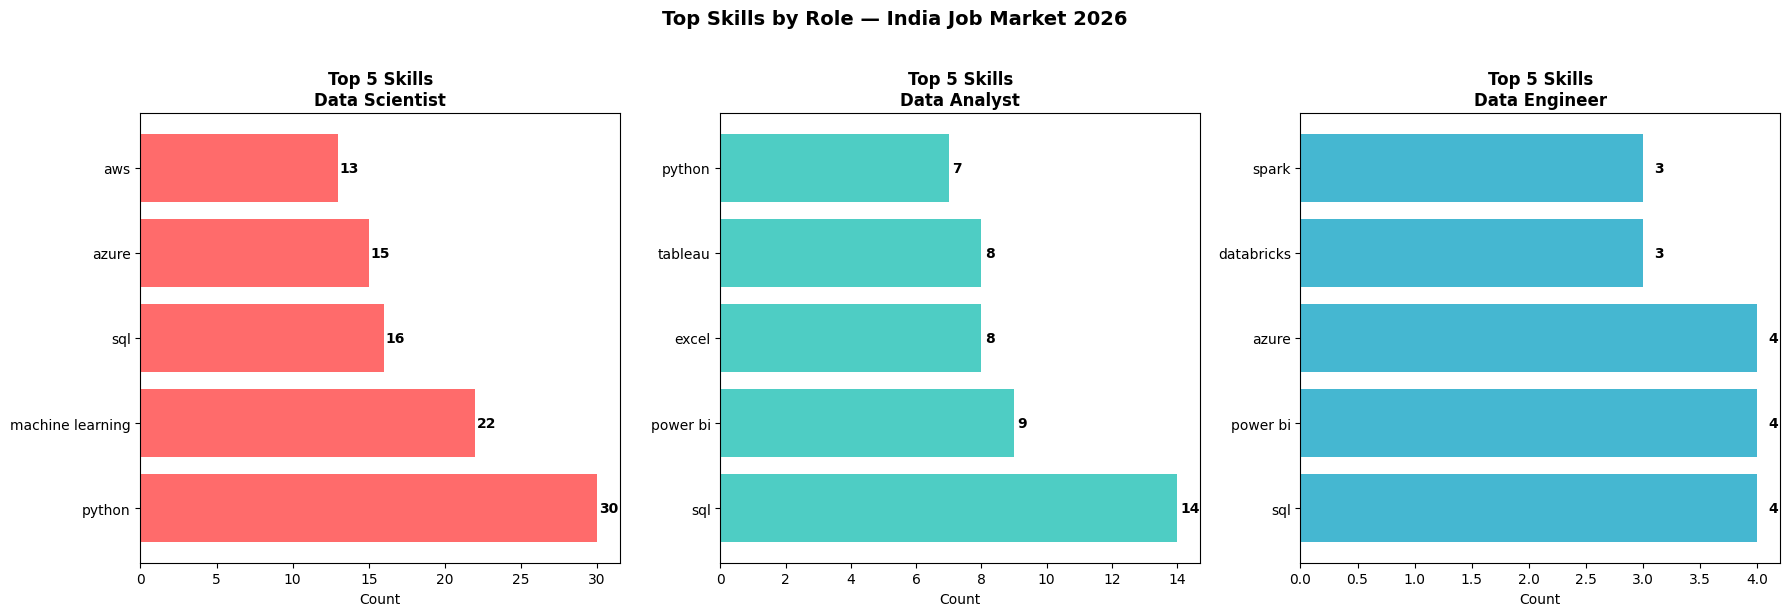

Chart 4 saved!


In [9]:
# ─── Chart 4: Top 5 Skills by Role ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

roles = ['Data Scientist', 'Data Analyst', 'Data Engineer']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, role in enumerate(roles):
    # Filter jobs for this role
    role_job_ids = df_jobs[df_jobs['role_searched'] == role]['id'].tolist()
    
    # Get skills for these jobs
    role_skills = df_skills[df_skills['job_id'].isin(role_job_ids)]
    top_skills = role_skills['skill'].value_counts().head(5)
    
    axes[i].barh(top_skills.index, top_skills.values, color=colors[i])
    axes[i].set_title(f'Top 5 Skills\n{role}', 
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Count')
    
    # Value labels
    for j, v in enumerate(top_skills.values):
        axes[i].text(v + 0.1, j, str(v), va='center', fontweight='bold')

plt.suptitle('Top Skills by Role — India Job Market 2026',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart4_skills_by_role.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

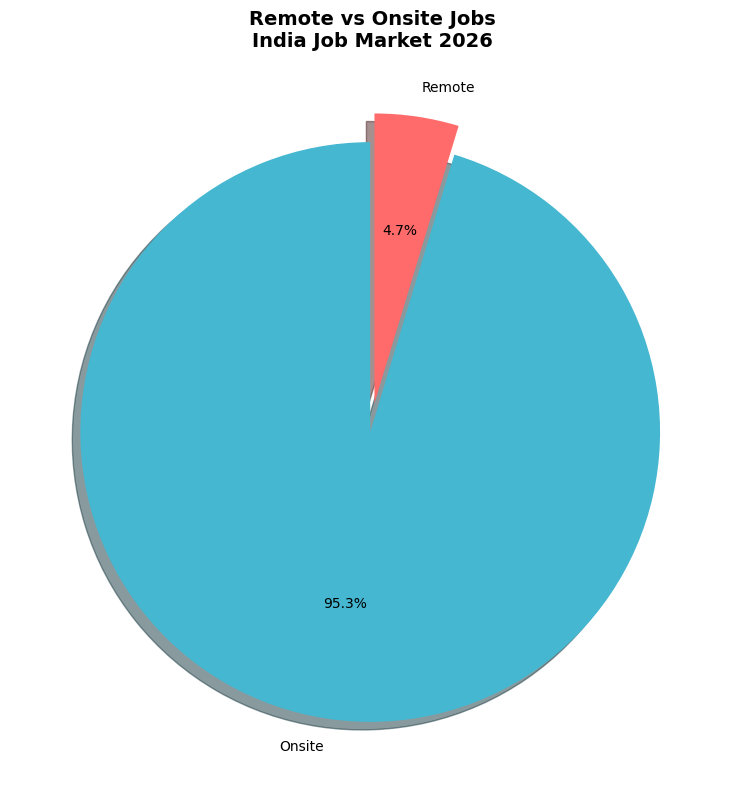

In [11]:
# ─── Chart 5: Remote vs Onsite ───────────────────
plt.figure(figsize=(8, 8))

df_jobs['work_type'] = df_jobs['job_title'].apply(
    lambda x: 'Remote' if 'remote' in str(x).lower() else 'Onsite'
)

work_counts = df_jobs['work_type'].value_counts()

colors = ['#45B7D1', '#FF6B6B']
explode = (0.05, 0.05)

plt.pie(work_counts.values,
        labels=work_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        shadow=True,
        startangle=90)

plt.title('Remote vs Onsite Jobs\nIndia Job Market 2026',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_remote_onsite.png', dpi=150, bbox_inches='tight')
plt.show()